# $$ \textbf{Sinais e Sistemas Dinâmicos - Aula 05}$$


Este Notebook é utilizado para o estudo da disciplina  **Sinais e Sistemas Dinâmicos** através da bibliografia 

- [Análise Linear de Sinais, José C. Geromel, Grace S. Deaecto. ed. Blucher, 2019]

- [Análise Linear de Sistemas Dinâmicos, José C. Geromel, Alvaro G. B. Palhares. ed. Blucher, 2019.]

Quando aplicável utilizaremos a tolboox processamento de sinais *scipy*, a biblioteca de computação simbólica *sympy*, dentre outras que se fizerem necessárias, do Python.


In [1]:
## Importação das bibliotecas Python, como indicado no texto ##

# biblioteca Python para matemática simbólica 
import sympy as sym
from sympy import* 

# Pacote para computação científica
import numpy as np

# biblioteca para a visualização de dados em Python.
import matplotlib.pyplot as plt

from pylab import plot, show

# Este módulo fornece acesso às funções matemáticas (definidas pelo padrão C)
import math

# cmath permite operações com números complexos
import cmath

# O módulo de frações fornece suporte para aritmética de números racionais
from fractions import Fraction

# permite usar latex para exibir equações matemáticas no Jupyter Notebook
from IPython.display import display, Math

#toolbox de processamento de sinais
from scipy import signal 

## 3. Sistemas

De forma bastante genérica, um **sistema** é *todo dispositivo que processa sinais*. Um sistema pode ser representado na forma de um diagrama de blocos como ilustrado na Figura 2.5. 

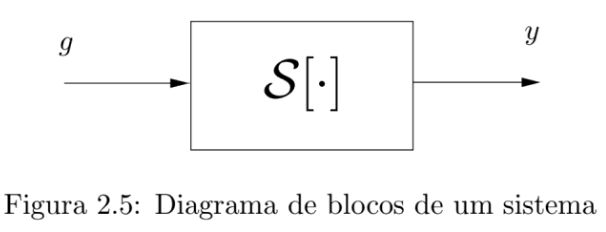

Ele atua no sinal $g$ presente na sua entrada e fornece como resultado o sinal $y$ que disponibiliza na sua saída. Nosso propósito é estudar os **sistemas** denominados **dinâmicos** *cuja saída depende não só da entrada em um determinado instante, mas eventualmente de todo o seu passado*.

Um sistema é completamente caracterizado pelo operador $\mathcal{S}[\cdot]$, que nada mais é que uma relação matemática que permite determinar o sinal de saída $y$ como resposta ao sinal de entrada $g$, ou seja,
$$
y=\mathcal{S}[g]
$$
Para ficar mais claro, imaginemos um sistema a tempo contínuo composto por um resistor com resistência $R[\Omega]$. Tomamos como entrada o sinal de tensão $g$ em $[V]$ colocado nos seus terminais e como saída o sinal de corrente resultante em $[A]$. A lei de Ohm imediatamente fornece $S[g]=g / R$. Trata-se de um **sistema** denominado **algébrico**, pois a *sua saída, em cada instante de tempo, depende da entrada apenas naquele mesmo instante*. 

Se o resistor for trocado por um indutor com indutância $L[H]$ o novo sistema é caracterizado pelo operador
$$
\mathcal{S}[g]=\frac{1}{L} \int_{-\infty}^t g(\tau) d \tau
$$
onde se assume que no início do tempo $t=-\infty$ o sistema estava isolado, inoperante. Nota-se que agora o valor da saida $y(t)$ em um determinado instante $t \in \mathbb{R}$ depende de toda a história da entrada $\{g(\tau), \forall \tau \leq t\}$ até aquele instante. 

Assim como os sinais, existem **sistemas a tempo contínuo** e **sistemas a tempo discreto**. Os primeiros processam sinais com domínio $t \in \mathbb{R}$, enquanto que os últimos processam sinais com domínio $k \in \mathbb{Z}$. Independentemente desta característica importante, os sistemas são classificados segundo as seguintes classes que colocam em evidência as suas características mais relevantes:


- **Sistemas lineares**: sāo aqueles que respeitam o **Princípio da Superposiçāo**. Se $y_i$ é a saída correspondente à entrada $g_i$ para todo $i=1,2, \cdots, m$ então $y=\sum_i \alpha_i y_i$ é a saída correspondente à entrada $g=\sum_i \alpha_i g_i$. Assim sendo, para todas entradas $g_i$ e escalares $\alpha_i$ com $i=1,2, \cdots, m$ temos
$$
\mathcal{S}\left[\sum_{i=1}^m \alpha_i g_i\right]=\sum_{i=1}^m \alpha_i \mathcal{S}\left[g_i\right]
$$
o que torna evidente que a linearidade do sistema preserva na saída a mesma combinação linear da entrada.

- **Sistemas invariantes no tempo**: são assim chamados quando um atraso arbitrário na entrada implicar o mesmo atraso na saída. Sendo $g(t)$ e $y(t)$ sinais de entrada e de saída que, portanto, satisfazem a relação $y=\mathcal{S}[g]$, se definirmos os sinais atrasados $g_\tau(t)=g(t-\tau)$ e $y_\tau(t)=y(t-\tau)$, então
$$
y_\tau=\mathcal{S}\left[g_\tau\right]
$$
Para esta classe de sistemas podemos arbitrar, sem perda alguma, o instante inicial $t_0=0$ em que sua resposta começa a ser calculada.
- **Sistemas causais**: causalidade é um importante conceito que também é bastante intuitivo. A sua saída $y(t)$ depende apenas da entrada $g(\tau)$ para todo $\tau \leq t$. Ou seja, um sistema causal só pode ser influenciado pelo passado e pelo presente, jamais pelo futuro. *Apenas os sistemas causais podem ser realizados*.

Neste curso trataremos sobretudo os **sistemas lineares invariantes no tempo**, identificados pela sigla (**LIT**), e causais. Esse é, sem dúvida, o caso mais importante não só pelas suas implicações teóricas, mas também por sua ampla utilização prática. A seguir, tendo em vista a importância e as particularidades de cada um deles, passamos a estudar separadamente os sistemas LIT a tempo contínuo e a tempo discreto.


### 3.1 Sistemas a Tempo Contínuo
A análise de sistemas a tempo contínuo tem como base a chamada operação de **convolução** de dois sinais. Sejam dois sinais $g(t)$ e $h(t)$ com domínio $\mathbb{R}$ e imagem $\mathbb{R}$. A convolução de $g$ por $h$, denotada por $g * h$, tem como resultante um outro sinal $f(t)$ com mesmo domínio e mesmo conjunto imagem, dado por
$$
f(t)=g * h=\int_{-\infty}^{\infty} g(\tau) h(t-\tau) d \tau
$$
Esta operação é associativa, distributiva e comutativa. 

Em particular, esta última propriedade decorre da mudança da variável de integração. De fato, definindo a nova variável $\xi=t-\tau$, vem
$$
\begin{aligned}
g * h & =\int_{-\infty}^{\infty} g(\tau) h(t-\tau) d \tau \\
& =\int_{-\infty}^{\infty} g(t-\xi) h(\xi) d \xi \\
& =h * g
\end{aligned}
$$

que é o resultado desejado. Assim sendo, não há necessidade de se preocupar com qual sinal deve ser aquele que aparece atrasado no cálculo da integral, pois ambas as possibilidades fornecem o mesmo resultado. 

Um caso particular tem importância singular. Trata-se da convolução de um sinal $g(t)$ com o impulso unitário $\delta(t)$, que resulta em
$$
g * \delta=\int_{-\infty}^{\infty} g(\tau) \delta(t-\tau) d \tau=g(t)
$$

Isto indica que **o impulso é o elemento neutro da operação de convolução**, tendo em vista que a convolução de qualquer sinal com o impulso unitário fornece o próprio sinal. 

Para se conhecer tudo a respeito de um sistema LIT representado pelo operador $\mathcal{S}[\cdot]$, basta conhecer a sua resposta ao impulso unitário denotada por
$$
h=\mathcal{S}[\delta]
$$

Isto quer dizer que todas as respostas possíveis sāo obtidas a partir desta resposta fundamental, como fica demonstrado no próximo teorema.

**Teorema 2.1** Para qualquer sinal de entrada $g(t)$ dado, o sinal de saída $y(t)$ de um sistema LIT definido por $y=\mathcal{S}[g]$ é dado por
$$
y(t)=g * h=\int_{-\infty}^{\infty} g(\tau) h(t-\tau) d \tau
$$
em que $h(t)$ é a sua resposta ao impulso unitário.

Prova: Escrevendo o sinal de entrada $g(t)$ como $g * \delta=\int_{-\infty}^{\infty} g(\tau) \delta(t-\tau) d \tau=g(t)$, assumindo que o sistema é LIT e calculando a saída correspondente, tem-se
$$
\begin{aligned}
y(t) & =\mathcal{S}\left[\int_{-\infty}^{\infty} g(\tau) \delta(t-\tau) d \tau\right] \\
& =\int_{-\infty}^{\infty} g(\tau) \mathcal{S}[\delta(t-\tau)] d \tau \\
& =\int_{-\infty}^{\infty} g(\tau) h(t-\tau) d \tau
\end{aligned}
$$
ou seja, $y=g * h$ como se desejava demonstrar. $\square$

É importante ficar claro que a linearidade do sistema foi utilizada na primeira igualdade para passar o operador $\mathcal{S}[\cdot]$ para dentro da integral e para retirar do seu interior a constante $g(\tau)$, tendo em vista que ele se aplica à variável $t \in \mathbb{R}$. Finalmente, como se trata de um sistema invariante no tempo, a terceira igualdade é obtida. O teorema foi provado sem que a causalidade fosse utilizada. 

De fato, como evidencia o próximo lema, a causalidade de um sistema se reflete na sua resposta ao impulso.

**Lema 2.3** Um sistema LIT definido por $y=\mathcal{S}[g]$ é causal quando a sua resposta ao impulso for tal que $h(t)=0$, $\forall t<0$.

Prova: Como a fórmula $y(t)=g * h=\int_{-\infty}^{\infty} g(\tau) h(t-\tau) d \tau$ é válida, calculando-a com $h(t)=0$ para todo $t<0$, obtemos
$$
y(t)=\int_{-\infty}^t g(\tau) h(t-\tau) d \tau
$$

desde que 

$$
y(t)=\int_{t}^{+ \infty}t g(\tau) h(t-\tau) d \tau = 0
$$

o que torna aparente que, apenas sob esta condição, a saída $y(t)$ depende da entrada $g(\tau)$ para todo $\tau \in(-\infty, t]$, provando assim o lema proposto. $\square$

Um caso especial, bastante frequente, ocorre quando o sinal de entrada for nulo para todo $t<0$. A aplicação do Lema 2.3 leva imediatamente a
 $$
y(t)=\left\{\begin{array}{cc}
\int_0^t g(\tau) h(t-\tau) d \tau, & t \geq 0 \\
0, & t<0
\end{array}\right.
$$
Como se trata de um sistema LIT causal o sinal de saída permanece nulo para todo $t<0$, pois o sinal de entrada é nulo neste mesmo intervalo de tempo. Este resultado é utilizado na resoluçāo dos exemplos discutidos em seguida, nos quais consideramos alguns sinais de entrada básicos, de grande ocorrência e utilidade no estudo de sinais e sistemas.

**Exemplo 2.14** (Resposta ao degrau unitário) Assumindo que o sistema seja LIT e considerando o sinal de entrada $g(t)=v(t)$ obtemos, pela aplicação direta de $y(t)=g * h=\int_{-\infty}^{\infty} g(\tau) h(t-\tau) d \tau$, a resposta correspondente na forma
$$
\begin{aligned}
y(t) & =\int_{-\infty}^{\infty} g(\tau) h(t-\tau) d \tau \\
& =\int_0^{\infty} h(t-\tau) d \tau \\
& =\int_{-\infty}^t h(\xi) d \xi
\end{aligned}
$$

onde realizamos a mudança de variável $\xi=t-\tau$ para obter a última igualdade. 

Se o sistema além de LIT for causal, teremos como resposta ao degrau unitário
$$
y(t)=\int_0^t h(\tau) d \tau
$$
para todo $t \geq 0$ e $y(t)=0$ para todo $t<0$. Desta forma, podemos concluir que a resposta ao degrau unitário é a integral da resposta ao impulso unitário.

**Exemplo 2.15** (Resposta ao sinal exponencial) O sinal de entrada é da seguinte forma $g(t)=e^{\lambda t}$ com $\lambda \in \mathbb{C}$. Este sinal tem domínio $\mathbb{R}$ e imagem $\mathbb{C}$. Assumindo que o sistema seja LIT, o resultado do Teorema 2.1 fornece
$$
\begin{aligned}
y(t) & =\int_{-\infty}^{\infty} e^{\lambda \tau} h(t-\tau) d \tau \\
& =\int_{-\infty}^{\infty} e^{\lambda(t-\xi)} h(\xi) d \xi \\
& =\left(\int_{-\infty}^{\infty} e^{-\lambda \xi} h(\xi) d \xi\right) e^{\lambda t}
\end{aligned}
$$

onde realizamos a mudança de variável $\xi=t-\tau$ para obter a segunda igualdade. 

Se o sistema em estudo também for causal, a sua reposta tem a forma mais simples
$$
y(t)=\left(\int_0^{\infty} e^{-\lambda \xi} h(\xi) d \xi\right) e^{\lambda t}
$$
válida para todo $t \in \mathbb{R}$. Nota-se que a quantidade entre parênteses só depende da resposta ao impulso do sistema em consideração e do parâmetro $\lambda \in \mathbb{C}$ que define o sinal de entrada. É uma constante em relação ao tempo que, ao ser denotada por $\hat{h}(\lambda)$, coloca em evidência que o sinal de saída é dado por $y(t)=\hat{h}(\lambda) e^{\lambda t}$, $\forall t \in \mathbb{R}$. 


Retomando $y=\mathcal{S}[g]$ obtemos, finalmente, a relação
$$
\mathcal{S}\left[e^{\lambda t}\right]=\hat{h}(\lambda) e^{\lambda t}
$$
que permite dizer que a funçāo exponencial $e^{\lambda t}, \forall t \in \mathbb{R}$, é uma autofunção e o escalar $\hat{h}(\lambda) \in \mathbb{C}$ é o respectivo autovalor do operador $\mathcal{S}[\cdot]$.  $\square$

Para um sistema causal é importante analisarmos como podemos identificar, isto é, determinar a sua resposta ao impulso $h(t)$ com domínio em $\mathbb{R}_{+}$. Para isso, escolhemos uma entrada do tipo exponencial $g(t)=e^{\lambda t} v(t) \operatorname{com} \lambda \in \mathbb{C}$ e assumimos que a saída correspondente, que é do tipo $y(t)=y_0(t) v(t)$, seja conhecida. Reescrevendo 
$$
y(t)=\left\{\begin{array}{cc}
\int_0^t g(\tau) h(t-\tau) d \tau, & t \geq 0 \\
0, & t<0
\end{array}\right.
$$
na forma alternativa
$$
y(t)=\int_0^t g(t-\tau) h(\tau) d \tau
$$
e substituindo os sinais que acabamos de descrever, vem
$$
\int_0^t e^{-\lambda \tau} h(\tau) d \tau=e^{-\lambda t} y_0(t) v(t), \forall t \in \mathbb{R}_{+}
$$

que é um equação integral que, ao ser resolvida, fornece $h(t)$ para todo $t \in \mathbb{R}_{+}$. Nota-se que a solução deste problema é obtida pela derivação em relação ao tempo dos dois membros desta igualdade, mas para isso é preciso saber derivar o degrau unitário que nem mesmo é uma função contínua em $t=0$. 

Como será visto mais adiante, isto pode ser feito a partir da generalização do conceito de derivada que resulta do estudo da Transformada de Fourier. Essas consideraçōes permitem concluir que $d v(t) / d t=\delta(t)$. 

Derivando $\int_0^t e^{-\lambda \tau} h(\tau) d \tau=e^{-\lambda t} y_0(t) v(t), \quad \forall t \in \mathbb{R}_{+}$ em relação ao tempo, com algumas manipulações algébricas, obtemos
$$
h(t)=\left(\dot{y}_0(t)-\lambda y_0(t)\right) v(t)+y_0(0) \delta(t)
$$
em que utilizamos a propriedade do impulso unitário $y_0(t) \delta(t)=y_0(0) \delta(t)$. Em geral, ocorre que $y_0(0)=0$, pois o sinal de entrada é nulo para todo $t<0$ e o sistema em estudo parte do repouso. Neste caso, mais frequente, o impulso que aparece em $h(t)$ é eliminado.

 **Exemplo 2.16** Um circuito RC série é alimentado por uma tensão $g(t)$. Se escolhermos a tensão no capacitor como sendo a saída de interesse $y(t)$, a sua resposta ao impulso é dada por $y(t)=0$ para todo $t<0 $ e
$$
h(t)=\left(1 / c_0\right) e^{-t / c_0}, \forall t \geq 0
$$
em que $c_0=R C[\mathrm{~s}]$ é a sua constante de tempo. Portanto, a dimensão física de $h(t)$ é $\left[\mathrm{s}^{-1}\right]$. Trata-se, claro, de um sistema LIT causal. Como já vimos, a sua resposta a um degrau de amplitude $V_0[\mathrm{~V}]$, isto é, $g(t)=V_0 v(t)$ pode ser determinada por mera integração, ou seja,
$$
\begin{aligned}
y(t) & =V_0\left(1 / c_0\right) \int_0^t e^{-\tau / c_0} d \tau \\
& =V_0\left(1-e^{-t / c_0}\right)[\mathrm{V}]
\end{aligned}
$$
para todo $t \geq 0$ e $y(t)=0$ para todo $t<0$. Como a entrada considerada é igual ao degrau unitário multiplicado por $V_0$, apenas multiplicamos a saída correspondente pela mesma constante. Isto é possível pois o sistema é linear.

**Exemplo 2.17** Se no exemplo anterior substituirmos o resistor por um indutor com indutancia $L[\mathrm{H}]$, a resposta ao impulso torna-se $y(t)=0$ para todo $t<0$ e
$$
h(t)=\omega_0 \operatorname{sen}\left(\omega_0 t\right), \forall t \geq 0
$$
em que $\omega_0=1 / \sqrt{L C}[\mathrm{rad} / \mathrm{s}]$ é a sua frequência natural de oscilaçāo. Portanto, a dimensāo física de $h(t)$ é $[\mathrm{rad} / \mathrm{s}]$. O sinal de entrada que desejamos considerar é $g(t)=\cos (\omega t) v(t)$. 

O sinal de saída correspondente é dado em 
$$
y(t)=\left\{\begin{array}{cc}
\int_0^t g(\tau) h(t-\tau) d \tau & , \quad t \geq 0 \\
0 & , \quad t<0
\end{array}\right.
$$
isto é, $y(t)=0$ para todo $t<0 $ e
$$
\begin{aligned}
y(t) & =\omega_0 \int_0^t \cos (\omega \tau) \operatorname{sen}\left(\omega_0(t-\tau)\right) d \tau \\
& =\frac{\omega_0}{2} \int_0^t\left(\operatorname{sen}\left(\omega_0 t+\left(\omega-\omega_0\right) \tau\right)+\operatorname{sen}\left(\omega_0 t-\left(\omega+\omega_0\right) \tau\right)\right) d \tau \\
& =\frac{\omega_0^2}{\omega^2-\omega_0^2}\left(\cos \left(\omega_0 t\right)-\cos (\omega t)\right), \forall t \geq 0
\end{aligned}
$$
em que assumimos $\omega \neq \omega_0$. 

Para $\omega=\omega_0$ as contas podem ser refeitas para se obter
$$
y(t)=\frac{\omega_0}{2} t \operatorname{sen}\left(\omega_0 t\right), \forall t \geq 0
$$
e neste caso, um sinal de entrada limitado em um sistema com resposta ao impulso limitada produz um sinal de saída ilimitado. Este fenômeno é chamado de **ressonância** e ocorre quando a resposta ao impulso e o sinal entrada são sinais periódicos com a mesma frequência natural ou, equivalentemente, com períodos iguais. Este comportamento será estudado com maiores detalhes em seguida. $\square$

In [2]:
w = sym.Symbol('w')
w0 = sym.Symbol('w0')
t = sym.Symbol('t')
T = sym.Symbol('T')
simplify(integrate(w0*cos(w*T)*sin(w0*(t - T)),(T,0,t)))

Piecewise((0, Eq(w, 0) & Eq(w0, 0)), (t*w0*sin(t*w0)/2, Eq(w, w0) | Eq(w, -w0)), (w0**2*(cos(t*w) - cos(t*w0))/(-w**2 + w0**2), True))

Um conceito fundamental relativo aos sistemas é o de **estabilidade**. De maneira nāo muito rigorosa, sistemas estáveis tendem a atenuar os sinais de entrada, enquanto que os instáveis tendem a amplificá-los. Por este motivo, **instabilidade** é um indicador de sérios problemas, sobretudo em sistemas físicos que podem ser levados a transitar longe dos seus pontos normais de operação.

**Definição 2.7 (Estabilidade)** Um **sistema** é **estável** se a todo sinal de entrada limitado corresponder um sinal de saída limitado.

Como vimos anteriormente, a resposta ao impulso unitário define o comportamento de qualquer sistema LIT. Dessa forma, para esta classe, a definição acima deve ser traduzida em alguma característica particular da sua resposta ao impulso. Como mostra o próximo teorema, isto de fato ocorre.

**Lema 2.4** Um sistema LIT com resposta ao impulso $h(t)$ é estável se e apenas se
$$
M_h=\int_{-\infty}^{\infty}|h(\tau)| d \tau
$$
for um valor finito.


Prova: Inicialmente, assumimos que $M_h=\int_{-\infty}^{\infty}|h(\tau)| d \tau$ é satisfeita e que a entrada é limitada, isto é, $|g(t)| \leq M_g<\infty$ para todo $t \in \mathbb{R}$. Com a resposta correspondente a esta entrada dada por $y(t)=g * h=\int_{-\infty}^{\infty} g(\tau) h(t-\tau) d \tau$, verificamos a partir de 
$$
\begin{aligned}
|y(t)| & =\left|\int_{-\infty}^{\infty} g(\tau) h(t-\tau) d \tau\right| \\
& \leq \int_{-\infty}^{\infty}|g(\tau)||h(t-\tau)| d \tau \\
& \leq M_g \int_{-\infty}^{\infty}|h(\xi)| d \xi=M_g M_h
\end{aligned}
$$
que ela é limitada para todo $t \in \mathbb{R}$ e assim concluímos que o sistema é estável. Inversamente, vamos calcular $y(0)$ para a entrada limitada $g(t)=1$ se $h(-t) \geq 0$ e $g(t)=-1$ se $h(-t) \leq 0$. Com a saída correspondente dada por $M_h=\int_{-\infty}^{\infty}|h(\tau)| d \tau$, temos
$$
\begin{aligned}
y(0) & =\int_{-\infty}^{\infty} g(\tau) h(-\tau) d \tau \\
& =\int_{-\infty}^{\infty}|h(-\tau)| d \tau \\
& =\int_{-\infty}^{\infty}|h(\xi)| d \xi=M_h
\end{aligned}
$$

e concluímos que a saída correspondente a esta entrada limitada será também limitada apenas se a constante $M_h$ for finita.

Para sistemas LIT causais a constante $M_h$ se simplifica para
$$
M_h=\int_0^{\infty}|h(\tau)| d \tau
$$
e fica claro que uma condição necessária (mas não suficiente) para que $M_h$ seja finita é que $\lim _{t \rightarrow+\infty}|h(t)|=0$. 

Uma condição suficiente para que isso ocorra é que existam constantes $\alpha>0$ e $\beta \geq 0$ tais que $|h(t)| \leq \beta e^{-\alpha t}$ para todo $t \in \mathbb{R}_{+}$, pois $M_h \leq \beta / \alpha$. Neste caso o sistema é dito **assintoticamente estável**. O gráfico do módulo da resposta ao impulso em função do tempo permite estimar esses parâmetros.

**Exemplo 2.18** Para um sistema LIT causal com resposta ao impulso da forma
$$
h(t)=\sum_{i=1}^n \theta_i e^{\lambda_i t}, \forall t \geq 0
$$
se $\operatorname{Re}\left(\lambda_i\right) \leq-\alpha<0$ para todo $i=1,2, \cdots, n$ verificamos imediatamente que com $\beta=\sum_{i=1}^n\left|\theta_i\right|$ a desigualdade $|h(t)| \leq \beta e^{-\alpha t}$ para todo $t \geq 0$ é verdadeira e a estabilidade assintótica é assegurada. Note que, se para algum $1 \leq i \leq n$ ocorrer $\operatorname{Re}\left(\lambda_i\right)>0,$ o sistema é instável. Neste contexto, o Exemplo 2.17 é emblemático. É claro que para aquele sistema tem-se $|h(t)| \leq \omega_0$ e $\alpha=0$. Ele não obedece a definição de estabilidade, pois a constante $M_h=+\infty$, isto é, torna-se ilimitada. Por este motivo, e levando em consideração que a condiçāo do Lema 2.3 é necessária e suficiente, existe um sinal de entrada limitado cuja saída correspondente é ilimitada.

### 3.2 Sistemas a Tempo Discreto
Como ocorreu com o estudo de sinais, o de sistemas a tempo discreto é bastante parecido com o que foi feito para os sistemas a tempo contínuo. Mesmo assim, mais uma vez, vale a pena colocar em evidência as similitudes e as eventuais diferenças das ferramentas matemáticas que são utilizadas. A operação de base é a convolução de dois sinais $g(k)$ e $h(k)$ com domínio $\mathbb{Z}$ e imagem $\mathbb{R}$. A convolução de $g$ por $h$, denotada por $g * h$, tem como resultante um outro sinal $f(k)$ com mesmo domínio e mesmo conjunto imagem, dado por
$$
f(k)=g * h=\sum_{n=-\infty}^{\infty} g(n) h(k-n)
$$

A notação utilizada para convolução em tempo discreto é a mesma que foi adotada para sinais em tempo contínuo. O contexto define de forma inequívoca em qual domínio estamos operando. Trata-se de uma operação associativa, distributiva e comutativa. Em particular, esta última propriedade pode ser verificada com a mudança de variável $m=k-n$, que permite calcular
$$
\begin{aligned}
g * h & =\sum_{n=-\infty}^{\infty} g(n) h(k-n) \\
& =\sum_{m=-\infty}^{\infty} g(k-m) h(m) \\
& =h * g
\end{aligned}
$$
que é o que se desejava obter. Como os resultados finais são idênticos, não é preciso se preocupar com qual das duas fórmulas se deve operar em cada caso específico. A importante operação de convolução de um sinal $g(k)$ com o impulso unitário $\delta(k)$ decorre imediatamente da definição, que, neste caso, fornece
$$
g * \delta=\sum_{n=-\infty}^{\infty} g(n) \delta(k-n)=g(k)
$$
Isto indica que o impulso é o elemento neutro da operação de convolução tendo em vista que a convoluçāo de qualquer sinal com o impulso unitário fornece o próprio sinal. Para se conhecer tudo a respeito de um sistema LIT representado pelo operador $\mathcal{S}[\cdot]$, basta conhecer a sua resposta ao impulso unitário denotada por
$$
h=\mathcal{S}[\delta]
$$

Isto quer dizer que todas as respostas possíveis são obtidas a partir desta resposta fundamental, como fica demonstrado no próximo teorema, que é bastante similar à sua versão em tempo contínuo.



**Teorema 2.2** Para qualquer sinal de entrada $g(k)$ dado, o sinal de saida $y(k)$ de um sistema LIT definido por $
y=\mathcal{S}[g] $ é dado por
$$
y(k)=g * h=\sum_{n=-\infty}^{\infty} g(n) h(k-n)
$$
em que $h(k)$ é a sua resposta ao impulso unitário.


Prova: Escrevendo o sinal de entrada $g(k)$ como $g * \delta=\sum_{n=-\infty}^{\infty} g(n) \delta(k-n)=g(k)
$, assumindo que o sistema é LIT e calculando a saída correspondente, obtemos
$$
\begin{aligned}
y(k) & =\mathcal{S}\left[\sum_{n=-\infty}^{\infty} g(n) \delta(k-n)\right] \\
& =\sum_{n=-\infty}^{\infty} g(n) \mathcal{S}[\delta(k-n)] \\
& =\sum_{n=-\infty}^{\infty} g(n) h(k-n)
\end{aligned}
$$
ou seja, $y=g * h$, como se desejava demonstrar. $\square$



Exatamente como foi feito no caso a tempo contínuo, a linearidade do sistema foi utilizada na primeira igualdade para passar o operador $\mathcal{S}[\cdot]$ para dentro da soma e para retirar do seu interior a constante $g(n)$, pois ele se aplica à variável independente $k \in \mathbb{Z}$. Finalmente, a invariância no tempo faz com que a terceira igualdade seja obtida. O teorema foi provado sem que a causalidade tenha sido utilizada. De fato, como evidencia o próximo lema, a causalidade de um sistema a tempo discreto também se reflete na sua resposta ao impulso.

**Lema 2.4** Um sistema LIT definido por $y=\mathcal{S}[g]$ é causal quando a sua resposta ao impulso for tal que $h(k)=0, \forall k<0$.

Prova: Levando em conta que $y(k)=g * h=\sum_{n=-\infty}^{\infty} g(n) h(k-n)$ (Teorema 2.2) e usando o fato de que $h(k)=0, \forall k<0$, obtemos
$$
y(k)=\sum_{n=-\infty}^k g(n) h(k-n)
$$

fazendo com que $y(k)$ dependa exclusivamente de $g(n)$ para todo $n \in(-\infty, k]$, o que prova o lema proposto. $\square$

Um caso especial, bastante frequente, ocorre quando o sinal de entrada for nulo para todo $k<0$. A aplicação do Lema 2.4 leva imediatamente a
$$
y(k)=\left\{\begin{array}{cc}
\sum_{n=0}^k g(n) h(k-n), & k \geq 0 \\
0, & k<0
\end{array}\right.
$$
A resposta assim obtida deriva especialmente da causalidade e da classe especial dos sinais de entrada. Este resultado é utilizado na resolução dos exemplos discutidos em seguida, nos quais consideramos alguns sinais de entrada básicos e de grande ocorrência no estudo de sinais e sistemas a tempo discreto.

**Exemplo 2.19** (Resposta ao degrau unitário) Assumindo que o sistema seja LIT e considerando o sinal de entrada $g(k)=v(k)$ obtemos, pela aplicação direta de $y(k)=g * h=\sum_{n=-\infty}^{\infty} g(n) h(k-n)$, a resposta correspondente na forma
$$
\begin{aligned}
y(k) & =\sum_{n=-\infty}^{\infty} g(n) h(k-n) \\
& =\sum_{n=0}^{\infty} h(k-n) \\
& =\sum_{m=-\infty}^k h(m)
\end{aligned}
$$
onde realizamos a mudança de variável $m=k-n$ para obter a última igualdade. 

Se o sistema além de LIT for causal, teremos como resposta ao degrau unitário
$$
y(k)=\sum_{n=0}^k h(n)
$$
para todo $k \geq 0$ e $y(k)=0$ para todo $k<0$. Ou seja, para obter a resposta ao degrau unitário basta somar a resposta ao impulso.

**Exemplo 2.20** (Resposta ao sinal geométrico) O sinal de entrada é da seguinte forma $g(k)=\lambda^k \operatorname{com} \lambda \in \mathbb{C}$. Este sinal tem domínio $\mathbb{Z}$ e imagem $\mathbb{C}$. Observe que os seus elementos formam uma progressāo geométrica. Assumindo que o sistema seja LIT, o resultado do Teorema 2.2 fornece
$$
\begin{aligned}
y(k) & =\sum_{n=-\infty}^{\infty} \lambda^n h(k-n) \\
& =\sum_{m=-\infty}^{\infty} \lambda^{(k-m)} h(m) \\
& =\left(\sum_{m=-\infty}^{\infty} \lambda^{-m} h(m)\right) \lambda^k
\end{aligned}
$$
onde realizamos a mudança de variável $m=k-n$ para obter a segunda igualdade. Se o sistema em estudo também for causal, a sua resposta tem a forma mais simples
$$
y(k)=\left(\sum_{m=0}^{\infty} \lambda^{-m} h(m)\right) \lambda^k
$$
válida para todo $k \in \mathbb{Z}$. Nota-se que a quantidade entre parênteses só depende da resposta ao impulso do sistema em consideraçāo e do parâmetro $\lambda \in \mathbb{C}$ que define o sinal de entrada. É uma constante em relação ao tempo que, ao ser denotada por $\hat{h}(\lambda)$, coloca em evidência que o sinal de saída é dado por $y(k)=\hat{h}(\lambda) \lambda^k, \forall k \in \mathbb{Z}$. 

Retomando $y=\mathcal{S}[g]$, obtemos, finalmente, a relação
$$
\mathcal{S}\left[\lambda^k\right]=\hat{h}(\lambda) \lambda^k
$$
que permite dizer que a funçāo geométrica $\lambda^k, \forall k \in \mathbb{Z}$, é uma autofunção e o escalar $\hat{h}(\lambda) \in \mathbb{C}$ é o respectivo autovalor do operador $\mathcal{S}[\cdot]$.


**Exemplo 2.21** A resposta ao impulso de um sistema LIT causal é dada por $h(k)=$ $a^k v(k)$, em que $a \in \mathbb{R}$. Para o sinal de entrada $g(k)=\cos (\theta k) v(k) \operatorname{com} \theta \in[0,2 \pi]$, a saída correspondente pode ser calculada através de: 

$$
y(k)=\left\{\begin{array}{cc}
\sum_{n=0}^k g(n) h(k-n), & k \geq 0 \\
0, & k<0
\end{array}\right.
$$


Como já vimos, para realizar somas é mais conveniente expressar as funções trigonométricas através de exponenciais complexas, ou seja,
$$
g(k)=\frac{1}{2}\left(e^{j \theta k}+e^{-j \theta k}\right) v(k)
$$

e, assim, $y(k)=0$ para todo $k<0 $ e
$$
\begin{aligned}
y(k) & =\sum_{n=0}^k g(n) h(k-n) \\
& =\frac{a^k}{2} \sum_{n=0}^k\left(e^{j \theta n}+e^{-j \theta n}\right) a^{-n} \\
& =\frac{(a-\cos (\theta)) a^{k+1}+\cos (\theta k)-a \cos (\theta(k+1))}{a^2-2 a \cos (\theta)+1}, \forall k \geq 0
\end{aligned}
$$
onde utilizamos o Lema 2.1 para calcular os valores das duas somas, lembrando que é preciso exigir que $e^{j \theta} / a \neq 1$ e $e^{-j \theta} / a \neq 1$. Tomemos o caso particular em que $\theta=0$. A fórmula acima se reduz a
$$
y(k)=\frac{1-a^{k+1}}{1-a}, \quad \forall k \geq 0
$$
que é o resultado esperado, pois $g(k)=v(k)$ e, portanto, no instante $k \in \mathbb{N}$ a saída deve ser igual à soma dos $k+1$ primeiros elementos de uma progressāo geométrica com razāo a. A solução para $a=1$ pode ser calculada pelo limite de $y(k)$ para $a \rightarrow 1$, ou seja, $y(k)=(k+1) v(k)$. Ocorre novamente o fenômeno da ressonância, pois, para um sinal de entrada limitado (degrau unitário) e para um sistema com resposta ao impulso limitada (degrau unitário), o sinal de saída correspondente é ilimitado. $\square$

O conceito de estabilidade é fundamental e básico no contexto de sistemas a tempo contínuo e também a tempo discreto. A Definição 2.7 de estabilidade dada anteriormente permanece a mesma em ambos os casos. Naturalmente, como a resposta ao impulso define completamente o comportamento de um sistema, a exigência de ser estável deve ser traduzida em alguma propriedade específica desta função. O próximo lema explicita esta propriedade.



**Lema 2.5** Um sistema LIT com resposta ao impulso $h(k)$ é estável se e apenas se
$$
M_h=\sum_{n=-\infty}^{\infty}|h(n)|
$$
for um valor finito.

Prova: Inicialmente, assumimos que a equação acima é satisfeita e que a entrada é limitada, isto é, $|g(k)| \leq M_g<\infty$ para todo $k \in \mathbb{Z}$. Com a resposta correspondente a esta entrada, verificamos a partir de
$$
\begin{aligned}
|y(k)| & =\left|\sum_{n=-\infty}^{\infty} g(n) h(k-n)\right| \\
& \leq \sum_{n=-\infty}^{\infty}|g(n)||h(k-n)| \\
& \leq M_g \sum_{m=-\infty}^{\infty}|h(m)|=M_g M_h
\end{aligned}
$$
que ela é limitada para todo $k \in \mathbb{Z}$ e assim concluímos que o sistema é estável. Inversamente, vamos calcular $y(0)$ para a entrada limitada $g(k)=1$ se $h(-k) \geq 0$ e $g(k)=-1$ se $h(-k) \leq 0$. Com a saída correspondente dada por (2.67), temos
$$
\begin{aligned}
y(0) & =\sum_{n=-\infty}^{\infty} g(n) h(-n) \\
& =\sum_{n=-\infty}^{\infty}|h(-n)| \\
& =\sum_{m=-\infty}^{\infty}|h(m)|=M_h
\end{aligned}
$$
e concluímos que a saída correspondente a esta entrada limitada será também limitada apenas se $M_h$ for um valor finito. $\square$

Para sistemas LIT causais a tempo discreto, a constante $M_h$ se simplifica para
$$
M_h=\sum_{n=0}^{\infty}|h(n)|
$$
e uma condiçāo necessária (mas nāo suficiente) para que $M_h$ seja finita é que $\lim _{k \rightarrow+\infty}|h(k)|=0$. Por outro lado, uma condição suficiente para que isso ocorra é que existam constantes $|\alpha|<1$ e $\beta \geq 0$ tais que $|h(k)| \leq \beta \alpha^k$ para todo $k \in \mathbb{N}$ pois $M_h=\beta /(1-\alpha)$. Neste caso, o sistema é assintoticamente estável.

Com vimos, qualquer sistema LIT a tempo contínuo ou a tempo discreto é completamente definido por sua resposta ao impulso unitário. Trata-se de um atributo específico de cada sistema. Por este motivo, para se conhecer um sistema LIT de interesse é preciso determinar a sua resposta ao impulso através de simulações ou ensaios práticos. Isto é feito através do estabelecimento de um modelo matemático que leva em conta as leis básicas que definem o seu comportamento. Desta forma, é preciso se preocupar em aprender e usar de forma correta a modelagem matemática de sinais e sistemas.